## Modèle de base - Random Forest

In [1]:
# Import des librairies

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor
from src.utils.TransformData import dataframe_merge, code_insee_from_communes_as_dict

## ML + evaluation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [2]:
# Chargement et preprocessing des données de training et de evaluation

##1. Pre-process training data (scaler and encoder are saved during this process)
train_processor = DataProcessor(mode="training")
df_train = train_processor.run()  #fit training set and save arguments (scaler, ordinal map, target_encoding_maps, ...)

##2. Pre-process test data (by using the same scaler/encoder fitted on training dataset)
test_processor = DataProcessor(mode="validation")

#  HERE:  Reuse the same pre-processor fitted on training dataset (so no data-leakage with target-encoding, normalisation...)
test_processor.target_encoding_maps = train_processor.target_encoding_maps
test_processor.ordinal_maps          = train_processor.ordinal_maps
test_processor.encoded_columns       = train_processor.encoded_columns
test_processor.scaler                = train_processor.scaler
test_processor.normalized_columns    = train_processor.normalized_columns

df_test = test_processor.run_transform() #pre-process test data using same args 

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail', 'client_nps_date_reponse_n_moins1_jours', 'client_nps_date_reponse_n_jours']
INFO:src.data_processing.data_processing:Columns that are One-hot encoded: ['client_mode_paiement', 'courtier_reseau_courtage', 'courtier_segmentation_interne', 'courtier_type_commission', 'recla_canal_entrant_principale', 'recla_canal_entrant_secondaire']
INFO:src.data_processing.data_processing:Columns that are Target encoded: ['client_ro_souscripteur', 'client_produit', 'client_garantie_base',

In [3]:
# check différences de colonnes
col_train = df_train.columns.to_list()
col_test = df_test.columns.to_list()

diff_train = list(set(col_train)-set(col_test))
diff_test = list(set(col_test)-set(col_train))
print(f"Dans train et pas dans test : {diff_train}")
print(f"Dans Test et pas dans train : {diff_test}")

Dans train et pas dans test : []
Dans Test et pas dans train : []


In [4]:
# Définition des X de train et de test et des y de train et de test
X_train = df_train.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal'], axis=1)
y_train = df_train['target_resiliation_6mois']
X_test = df_test.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal'], axis=1)
y_test = df_test['target_resiliation_6mois']

In [5]:
# Modèle de base
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=700, max_depth=10)
rf.fit(X_train, y_train)

# Ajustement jeu de test
y_pred_test = rf.predict(X_test)
y_proba_test = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
recall = recall_score(y_true=y_test, y_pred=y_pred_test)
f1 = f1_score(y_true=y_test, y_pred=y_pred_test)
precision = precision_score(y_true=y_test, y_pred=y_pred_test)
roc_auc = roc_auc_score(y_true=y_test, y_score=y_proba_test)


print("=========== Rapport Random Forest (test) ===========\n")
print(f"Score AUC du modèle sur le jeu de test : {roc_auc:.4f}")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print("===================================================\n")

=========== Rapport Random Forest (test) ===========

Score AUC du modèle sur le jeu de test : 0.7696
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     34549
           1       0.23      0.62      0.33      3900

    accuracy                           0.75     38449
   macro avg       0.59      0.69      0.59     38449
weighted avg       0.87      0.75      0.79     38449




In [6]:
# Modèle avec recherche des meilleurs hyperparamètre

## Initialiser un rf
rf = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

## Initialiser les paramètres du gridsearch
hp_space = {
    "n_estimators": [700, 100],
    "max_depth": [2, 4, 6 , 8, 10],
}

## Instancier le gridsearch
grid = GridSearchCV(
    estimator= rf,
    param_grid=hp_space,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5)
)

## Ajustement sur jeu d'entrainement
models = grid.fit(X_train, y_train)

## Récupération du meilleur model
best_model = grid.best_estimator_
print(f"Les meilleurs paramètres dans l'espace des hyperparamètres : {grid.best_params_} \n")

## extrapolation sur données de test
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

## Collecte des métriques d'évalution
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
recall = recall_score(y_true=y_test, y_pred=y_pred_test)
f1 = f1_score(y_true=y_test, y_pred=y_pred_test)
precision = precision_score(y_true=y_test, y_pred=y_pred_test)
roc_auc = roc_auc_score(y_true=y_test, y_score=y_proba_test)

print(f"Score AUC du modèle sur le jeu de test : {roc_auc:.4f}\n")

## Rapport de classification
print("=========== Rapport Random Forest (test) ===========\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print("===================================================\n")

Les meilleurs paramètres dans l'espace des hyperparamètres : {'max_depth': 2, 'n_estimators': 700} 

Score AUC du modèle sur le jeu de test : 0.7578

=========== Rapport Random Forest (test) ===========

              precision    recall  f1-score   support

           0       0.96      0.62      0.75     34549
           1       0.18      0.75      0.29      3900

    accuracy                           0.63     38449
   macro avg       0.57      0.69      0.52     38449
weighted avg       0.88      0.63      0.71     38449




L'aire en dessous de la courbe ROC est de 0.7578


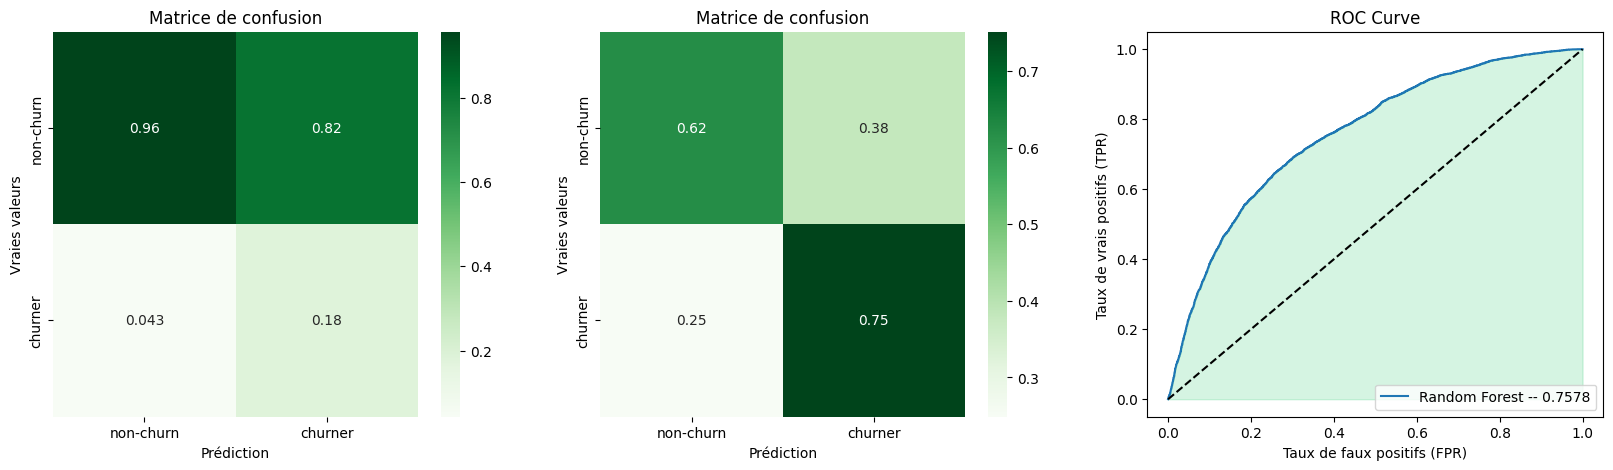

In [7]:
# Matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm1 = confusion_matrix(y_test, y_pred_test, normalize='pred')
sns.heatmap(cm1, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[0])
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Vraies valeurs')
axes[0].set_title("Matrice de confusion")

cm2 = confusion_matrix(y_test, y_pred_test, normalize='true')
sns.heatmap(cm2, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[1])
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Vraies valeurs')
axes[1].set_title("Matrice de confusion")

fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_proba_test)
axes[2].plot(fpr, tpr, label=f"Random Forest -- {roc_auc:.4f}")
axes[2].set_xlabel("Taux de faux positifs (FPR)")
axes[2].set_ylabel("Taux de vrais positifs (TPR)")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
axes[2].legend(loc='lower right', fontsize=10)
axes[2].set_title("ROC Curve")

print(f"L'aire en dessous de la courbe ROC est de {round(roc_auc, 4)}")
plt.show()

____

## Modèle 1 : Base + pondération des cotisation par le revenu médian par département (communes bruitées)

In [8]:
# Intégration du fichier INSEE du revenu median
revenu_median_dep = pd.read_excel(io="externals/revenu_median_departement.xlsx", sheet_name="Data", )
revenu_median_dep.head()

,Code,Libellé,Médiane du niveau de vie 2021
0,01,Ain,24810
1,02,Aisne,20920
2,03,Allier,21500
3,04,Alpes-de-Haute-Provence,21790
4,05,Hautes-Alpes,22010


In [9]:
# Récupération des dictionnaires en tenant compte de la spécificité Corse
dic_corse = {}
def create_dictionnary_of_code_insee(list_code_postal: list):
    for elem in list_code_postal:
        time.sleep(2)
        code_1 = ''
        code_2 = ''
        code_1, code_2 = code_insee_from_communes_as_dict(code_postal=elem)
        if len(code_1) != 0 and len(code_2) != 0:
            dic_corse[code_1] = code_2[:2]
            # print(f'Le code postal {code_1} a pour code insee {code_2}')

create_dictionnary_of_code_insee(list(df_train[df_train['client_departement']=='20']['client_code_postal'].unique()))
df_train['client_departement'] = (df_train['client_code_postal'].map(dic_corse).fillna(df_train['client_departement']))
df_test['client_departement'] = (df_test['client_code_postal'].map(dic_corse).fillna(df_test['client_departement']))

In [10]:
# Identification des communes de la base alptis absentes de la base insee
df_train['client_departement'] = df_train['client_departement'].astype(str).str.zfill(2)
df_test['client_departement'] = df_test['client_departement'].astype(str).str.zfill(2)
revenu_median_dep['Code'] = revenu_median_dep['Code'].astype(str).str.zfill(2)
revenu_median_dep['Médiane du niveau de vie 2021'] = revenu_median_dep['Médiane du niveau de vie 2021'].replace(to_replace='N/A - résultat non disponible', value=1.0).astype(float)
revenu_median_dep['Médiane du niveau de vie 2021'] .fillna(1.0)
left, df_train_dep, right = dataframe_merge(input_df1=df_train, input_df2=revenu_median_dep, id_1='client_departement', id_2='Code')
left, df_test_dep, right = dataframe_merge(input_df1=df_test, input_df2=revenu_median_dep, id_1='client_departement', id_2='Code')
print(f"Taille du left : {left.shape[0]}")
print(f"Taille du center : {df_train_dep.shape[0]}")
print(f"Taille du center : {df_test_dep.shape[0]}")
print(f"Taille du right : {right.shape[0]}")

/tmp/ipykernel_259135/3320992605.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  revenu_median_dep['Médiane du niveau de vie 2021'] = revenu_median_dep['Médiane du niveau de vie 2021'].replace(to_replace='N/A - résultat non disponible', value=1.0).astype(float)


Taille du left : 0
Taille du center : 132576
Taille du center : 38449
Taille du right : 101


In [11]:
# Pondération des montants de cotisation
df_train_dep['client_cotisations_annualisees_n'] = (df_train_dep['client_cotisations_annualisees_n']/df_train_dep['Médiane du niveau de vie 2021'])

In [12]:
# Définition des X de train et de test et des y de train et de test
X_train = df_train_dep.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal', 'client_departement', 'Libellé', 'Médiane du niveau de vie 2021', 'Code', '_merge'], axis=1)
y_train = df_train_dep['target_resiliation_6mois']
X_test = df_test_dep.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal', 'client_departement', 'Libellé', 'Médiane du niveau de vie 2021', 'Code', '_merge'], axis=1)
y_test = df_test_dep['target_resiliation_6mois']

In [13]:
# Modèle de base
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=700, max_depth=10)
rf.fit(X_train, y_train)

# Ajustement jeu de test
y_pred_test = rf.predict(X_test)
y_proba_test = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
recall = recall_score(y_true=y_test, y_pred=y_pred_test)
f1 = f1_score(y_true=y_test, y_pred=y_pred_test)
precision = precision_score(y_true=y_test, y_pred=y_pred_test)
roc_auc = roc_auc_score(y_true=y_test, y_score=y_proba_test)


print("=========== Rapport Random Forest (test) ===========\n")
print(f"Score AUC du modèle sur le jeu de test : {roc_auc:.4f}")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print("===================================================\n")

=========== Rapport Random Forest (test) ===========

Score AUC du modèle sur le jeu de test : 0.7682
              precision    recall  f1-score   support

         0.0       0.95      0.77      0.85     34549
         1.0       0.23      0.61      0.33      3900

    accuracy                           0.75     38449
   macro avg       0.59      0.69      0.59     38449
weighted avg       0.87      0.75      0.79     38449




In [14]:
# Modèle avec recherche des meilleurs hyperparamètre

## Initialiser un rf
rf = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

## Initialiser les paramètres du gridsearch
hp_space = {
    "n_estimators": [700, 100],
    "max_depth": [2, 4, 6 , 8, 10],
}

## Instancier le gridsearch
grid = GridSearchCV(
    estimator= rf,
    param_grid=hp_space,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5)
)

## Ajustement sur jeu d'entrainement
models = grid.fit(X_train, y_train)

## Récupération du meilleur model
best_model = grid.best_estimator_
print(f"Les meilleurs paramètres dans l'espace des hyperparamètres : {grid.best_params_} \n")

## extrapolation sur données de test
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

## Collecte des métriques d'évalution
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
recall = recall_score(y_true=y_test, y_pred=y_pred_test)
f1 = f1_score(y_true=y_test, y_pred=y_pred_test)
precision = precision_score(y_true=y_test, y_pred=y_pred_test)
roc_auc = roc_auc_score(y_true=y_test, y_score=y_proba_test)

print(f"Score AUC du modèle sur le jeu de test : {roc_auc:.4f}\n")

## Rapport de classification
print("=========== Rapport Random Forest (test) ===========\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print("===================================================\n")

Les meilleurs paramètres dans l'espace des hyperparamètres : {'max_depth': 10, 'n_estimators': 700} 

Score AUC du modèle sur le jeu de test : 0.7682

=========== Rapport Random Forest (test) ===========

              precision    recall  f1-score   support

         0.0       0.95      0.77      0.85     34549
         1.0       0.23      0.61      0.33      3900

    accuracy                           0.75     38449
   macro avg       0.59      0.69      0.59     38449
weighted avg       0.87      0.75      0.79     38449




L'aire en dessous de la courbe ROC est de 0.7682


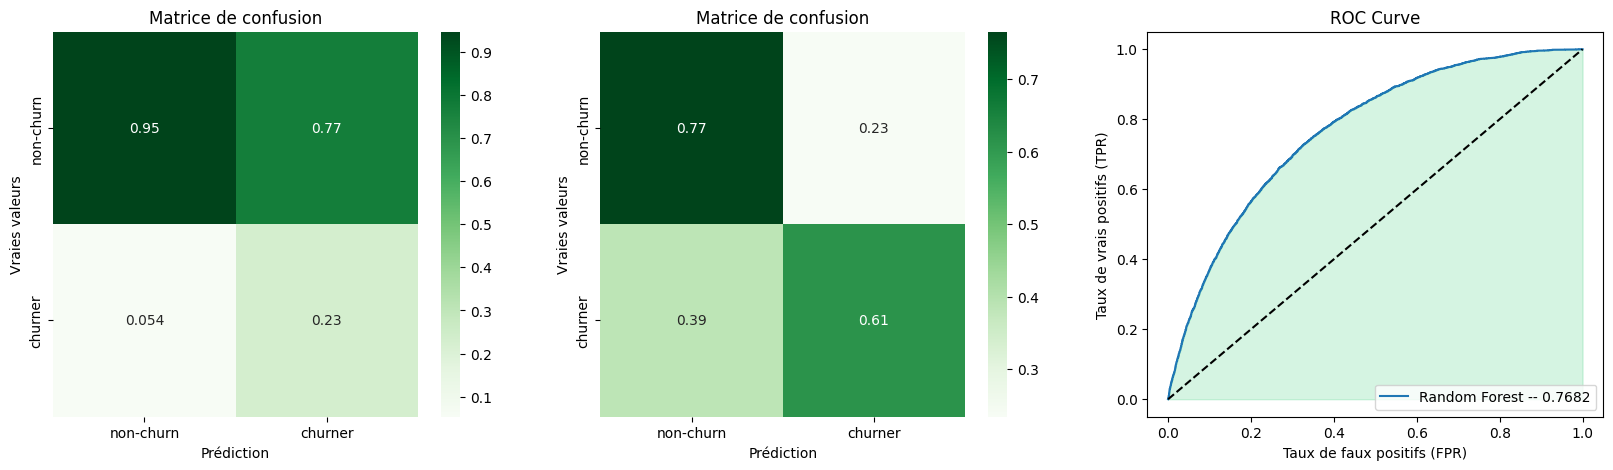

In [15]:
# Matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm1 = confusion_matrix(y_test, y_pred_test, normalize='pred')
sns.heatmap(cm1, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[0])
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Vraies valeurs')
axes[0].set_title("Matrice de confusion")

cm2 = confusion_matrix(y_test, y_pred_test, normalize='true')
sns.heatmap(cm2, annot=True, cmap='Greens',
            xticklabels=['non-churn', 'churner'],
            yticklabels=['non-churn', 'churner'],
            ax=axes[1])
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Vraies valeurs')
axes[1].set_title("Matrice de confusion")

fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_proba_test)
axes[2].plot(fpr, tpr, label=f"Random Forest -- {roc_auc:.4f}")
axes[2].set_xlabel("Taux de faux positifs (FPR)")
axes[2].set_ylabel("Taux de vrais positifs (TPR)")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
axes[2].legend(loc='lower right', fontsize=10)
axes[2].set_title("ROC Curve")

print(f"L'aire en dessous de la courbe ROC est de {round(roc_auc, 4)}")
plt.show()